# **Data Unterstanding - Olist Marketplace**

## **Zweck**
Dieses Notebook dokumentiert Struktur, Beziehungen und Datenqualität der Rohdaten.

Ziel ist die Bewertungen der strukturellen Integrität, Datenqualität und analytischen Eignung des Datensatzes.
Es werden keine Transformationen, Features oder Business-Interpretationen vorgenommen.

## **Inhaltsübersicht**

1. Datensatzüberblick  
2. Tabellenstruktur & Schema-Überblick 
3. ER-Diagramm  
4. Datenqualitätsprüfung  
- 4.1 Prüfung auf fehlende Werte 
- 4.2 Duplikate  
- 4.3 Logische Plausibilitätsprüfung  
5. Zeitliche Abdeckung  
6. Plausibilitätsprüfung von Verteilungen  
7. Fazit

## Technisches Setup

Initialisierung der DuckDB-Verbindung sowie Registrierung der Rohdaten.

In [2]:
import duckdb
from pathlib import Path

# Verbindung zur DuckDB (in-memory reicht völlig)
con = duckdb.connect()

# Hilfsfunktion für SQL-Abfragen
def sql(q):
    return con.sql(q).df()

# Projektpfad bestimmen (Notebook liegt in /notebooks)
DATA = Path("../data/raw/brazilian-ecommerce")

In [3]:
# Alle CSV-Dateien in DuckDB registrieren
for f in DATA.glob("*.csv"):
    name = f.stem.replace("olist_", "").replace("_dataset", "")
    
    con.sql(f"""
        CREATE OR REPLACE TABLE {name} AS
        SELECT * FROM read_csv_auto('{f.as_posix()}')
        """
           )
           
# Alle Tabellen anzeigen
sql("SHOW TABLES")

,name
0,customers
1,geolocation
2,order_items
3,order_payments
4,order_reviews
5,orders
6,product_category_name_translation
7,products
8,sellers


## **1. Datensatzüberblick**

Der Datensatz enthält Transaktionsdaten eines Online-Marketplaces.
Bestellungen verbinden Kunden, Händler, Produkte, Zahlungen, Bewertungen und Lieferinformationen.

Da die Informationen auf mehrere relationale Tabellen verteilt sind, muss zunächst deren Aufbau und Zusammenhang verstanden werden.

## **2. Tabellenstruktur & Schema-Überblick**

### Customer/Seller/Geolocation

| Column | Datenniveau | Description |
|------|------|------|
| customer_id | kategorisch (nominal) | Kunden-Order-ID |
| customer_unique_id | kategorisch (nominal) | Kunden-ID |
| customer_zip_code_prefix/seller_zip_code_prefix/geolocation_zip_code_prefix | kategorisch (nominal) | Kunden/Verkäufer/Geolocation Postleitzahl |
| customer_city/seller_city/geolocation_city | kategorisch (nominal) | Kunden/Verkäufer/Geolocation Stadt |
| customer_state/seller_state/geolocation_state | kategorisch (nominal) | Kunden/Verkäufer/Geolocation Bundesstaat |
| seller_id | kategorisch (nominal) | Verkäufer-ID |
| geolocation_lat | numerisch (`float`)  | Breitengrad |
| geolocation_Ing | numerisch (`float`) | Längengrad |

### Products
| Column | Datenniveau | Description |
|------|------|------|
| product_id | kategorisch (nominal) | eindeutige Produkt(Item)-ID |
| product_category_name | kategorisch (nominal) | Produkkategorie in Portugiesisch |
| product_name_lenght | numerisch (`int`) | Länge des Produktnames |
| product_description_lenght | numerisch (`int`) | Länge der Produktbeschreibung|
| product_photos_qty | numerisch (`int`) | Anzahl der Produktfotos|
| product_weight_g | numerisch (`float`) | Produktgewicht in gramm|
| product_length_cm | numerisch (`float`) | Produktlänge in cm|
| product_height_cm | numerisch (`float`) | Produkthöhe in cm|
| product_width_cm | numerisch (`float`) | Produktbreite in cm|


### Orders

Jede Zeile entspricht einer Bestellung.
enthält auch: customer_id

| Column | Datenniveau | Description |
|------|------|------|
| order_id | kategorisch (nominal) | eindeutige Bestell-ID |
| order_status | kategorisch (nominal) | Bestellstatus |
| order_purchase_timestamp | zeitlich (Timestamp) | Kaufzeitpunkt |
| order_approved_at | zeitlich (Datum) | Zeitpunkt der Zahlungsgenehmigung |
| order_delivered_carrier_date | zeitlich (Datum) | Zeipunkt an dem Bestellung an Logistikpartner übergeben wurde |
| order_delivered_customer_date | zeitlich (Datum) | Lieferdatum |
| order_estimated_delivery_date | zeitlich (Datum) | vorraussichtliches Lieferdatum |

### Orders_items

enthält auch: product_id, seller_id, order_id

| Column | Datenniveau | Description |
|------|------|------|
| order_item_id | kategorisch (nominal)| fortlaufende Nummer für Items IN EINER Bestellung |
| shipping_limit_date | zeitlich (Timestamp) | Zeitlimit des Verkäufers für die Übergabe an den Logistikpartner |
| price | numerisch (`float`) | Preis des Produktes(Items) |
| freight_value | numerisch (`float`) | anteilige Versandkosten für dieses Item |


### Orders_Payments
enthält auch: order_id

| Column | Datenniveau | Description |
|------|------|------|
| payment_sequential | ordinal (Reihenfolge(`int`))| Sortiert + nummeriert TEILZAHLUNGEN derselben Bestellung (1-n pro  order_id )! |
| payment_type | kategorisch (nominal)| Zahlungsart |
| payment_installments | kardinal (Anzahl(`int`)) | Ratenzahlung - Anzahl der vom Kunden gewählten Raten |
| payment_value | numerisch (`float`) | Zahlungswert |

### Orders_Reviews
enthält auch: order_id

| Column | Datenniveau | Description |
|------|------|------|
| review_id | kategorisch (nominal)| eindeutige Review-ID |
| review_score | ordinal (Skala(`int`))| Bewertung-Score - Sternebewertung 1-5|
| review_comment_title | nominal (Text(`str`)) | Review Kommentar-Titel |
| review_comment_message | nominal (Text(`str`))| Review Kommentar |
| review_creation_date | zeitlich (Datum)| Datum des Reviewerstellung |
| review_answer_timestamp | zeitlich (Timestamp) | Zeitstempel der Antwort auf die Review |

### Product_Category_Name_Translation
| Column | Datenniveau | Description |
|------|------|------|
| product_category_name_english | kategorisch (nominal(`str`)) | Produkkategorie in Englisch |
| product_category_name | kategorisch (nominal(`str`)) | Produkkategorie in Portugiesisch |


Hier kommen noch kurze Übersichten rein wie head(), info(), describe()

## **3. ER-Diagramm**

Das Entity-Relationship-Diagramm visualisiert die relationalen Strukturen und Primär-/Fremdschlüsselbeziehungen zwischen den Tabellen.  
Es dient als Grundlage für JOIN-Operationen und die spätere Feature-Generierung.

![Entity Relationship Diagram](../docs/olist_erd.png)

## **4. Datenqualitätsprüfung**

Vor der Analyse wird die strukturelle Vollständigkeit und logische Konsistenz der Daten überprüft.

###  4.1 Prüfung auf fehlende Werte

In [ ]:
# Prüfung der Kundenreferenz (Zuordnung von Bestellungen)  
sql("""
SELECT 
    COUNT(*) AS total_rows,
    SUM(customer_unique_id IS NULL) AS sum_missing_customer_uid
FROM customers
    """)

,total_rows,sum_missing_customer_uid
0,99441,0.0


Ergebnis: 

Keine kritischen fehlenden Werte.

In [7]:
#  Vollständigkeit KPI-relevanter Zeitstempel (Gesamtüberblick)
sql("""
SELECT
    COUNT(*) AS total_rows,
    SUM(order_purchase_timestamp IS NULL) AS missing_purchase_timestamp,
    SUM(order_delivered_customer_date IS NULL) AS missing_delivered_timestamp,
    SUM(order_estimated_delivery_date IS NULL) AS missing_estimated_timestamp
FROM orders
    """)

,total_rows,missing_purchase_timestamp,missing_delivered_timestamp,missing_estimated_timestamp
0,99441,0.0,2965.0,0.0


In [8]:
# Kritischer Check: Für ausgelieferte Bestellungen muss ein Lieferdatum vorhanden sein
sql("""
SELECT
    COUNT(*) AS delivered_orders,
    CAST(SUM(order_delivered_customer_date IS NULL) AS INTEGER) AS delivered_missing_delivery_date
FROM orders
WHERE order_status = 'delivered'
""")

,delivered_orders,delivered_missing_delivery_date
0,96478,8


Ergebnis:

Für 8 als „delivered“ klassifizierte Bestellungen fehlt das Lieferdatum. 
Diese Datensätze werden in der Datenaufbereitung berücksichtigt.

In [9]:
# Vollständigkeit der Preis- und Versandkostenangaben (Basis für Bestellwert/Umsatz)
sql("""
SELECT
    COUNT(*) AS total_rows,
    SUM(price IS NULL) AS missing_price,
    SUM(freight_value IS NULL) AS missing_freight_value
FROM order_items
    """)

,total_rows,missing_price,missing_freight_value
0,112650,0.0,0.0


Ergebnis:

Es liegen keine fehlenden Werte bei Artikelpreisen oder Versandkosten vor. 
Die Berechnung von Bestellwerten ist vollständig möglich.

In [10]:
# # Vollständigkeit der Zahlungsbeträge (Basis für Umsatzberechnung)
sql("""
SELECT
    COUNT(*) AS total_rows,
    SUM(payment_value IS NULL) AS missing_payment_value
FROM order_payments
    """)

,total_rows,missing_payment_value
0,103886,0.0


Ergebnis:

Zahlungsbeträge sind vollständig vorhanden. 
Die Aggregation von Umsätzen auf Order- und Customer-Level ist uneingeschränkt möglich.

In [11]:
# Vollständigkeit der Review Scores (Basis für Zufriedenheitsanalyse)
sql("""
SELECT
    COUNT(*) AS total_rows,
    SUM(review_score IS NULL) AS missing_review_score
FROM order_reviews
    """)

,total_rows,missing_review_score
0,99224,0.0


Ergebnis:

Es liegen keine fehlenden Review Scores vor. 
Die Bewertungsskala kann vollständig in der Zufriedenheitsanalyse berücksichtigt werden.

### 4.2 Duplikate

In [12]:
# Prüfung der Primärschlüssel-Eindeutigkeit (customer_id)
sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT customer_id) AS distinct_customer_id,
    COUNT(*) - COUNT(DISTINCT customer_id) AS duplicate_customer_id
FROM customers
    """)

,total_rows,distinct_customer_id,duplicate_customer_id
0,99441,99441,0


Ergebnis:

Die customer_id ist eindeutig und kann als Primärschlüssel der Tabelle customers betrachtet werden.

In [16]:
# Mehrfachvorkommen von customer_unique_id (Bestellungen pro Person)
sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT customer_unique_id) AS distinct_customer_unique_id,
    COUNT(*) - COUNT(DISTINCT customer_unique_id) AS repeat_customer_unique_id
FROM customers
    """)

,total_rows,distinct_customer_unique_id,repeat_customer_unique_id
0,99441,96096,3345


In [14]:
# Anzahl Kunden (customer_unique_id) mit mindestens zwei Bestellungen
sql("""
SELECT
    COUNT(*) AS repeat_customers
FROM (
    SELECT customer_unique_id
    FROM customers
    GROUP BY customer_unique_id
    HAVING COUNT(*) >= 2
) t
""")

,repeat_customers
0,2997


Ergebnis:

Ein Teil der Kunden (customer_unique_id) tritt mehrfach im Datensatz auf.
Insgesamt haben 2.997 Personen mindestens zwei Bestellungen getätigt.

Damit sind Retention- und Wiederkaufanalysen auf Personenebene möglich.

In [17]:
# Prüfung der Primärschlüssel-Eindeutigkeit (order_id)
sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_order_id,
    COUNT(*) - COUNT(DISTINCT order_id) AS duplicate_order_id
FROM orders
    """)

,total_rows,distinct_order_id,duplicate_order_id
0,99441,99441,0


Ergebnis:

Die order_id ist eindeutig und kann als Primärschlüssel der Tabelle orders betrachtet werden.
Eine doppelte Erfassung von Bestellungen liegt nicht vor.

In [18]:
# Prüfung der Primärschlüssel-Eindeutigkeit (seller_id)
sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT seller_id) AS distinct_seller_id,
    COUNT(*) - COUNT(DISTINCT seller_id) AS duplicate_seller_id
FROM sellers
    """)

,total_rows,distinct_seller_id,duplicate_seller_id
0,3095,3095,0


Ergebnis:

Die seller_id ist eindeutig und kann als Primärschlüssel der Tabelle sellers betrachtet werden.
Mehrfacherfassungen von Verkäufern liegen nicht vor.

In [19]:
# Prüfung der Primärschlüssel-Eindeutigkeit (product_id)
sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT product_id) AS distinct_product_id,
    COUNT(*) - COUNT(DISTINCT product_id) AS duplicate_product_id
FROM products
    """)

,total_rows,distinct_product_id,duplicate_product_id
0,32951,32951,0


Ergebnis:

Die product_id ist eindeutig und kann als Primärschlüssel der Tabelle products betrachtet werden.
Mehrfacherfassungen von Produkten liegen nicht vor.

### **4.3 Logische Plausibilitätsprüfungen**

In diesem Abschnitt werden logische Inkonsistenzen geprüft, die KPI-Berechnungen verfälschen würden.

Dazu gehören u. a. zeitliche Widersprüche (z. B. Lieferung vor Kauf), Werte außerhalb gültiger Skalen sowie negative monetäre Werte.

In [20]:
# Prüft zeitliche Inkonsistenz: Lieferdatum liegt vor Kaufzeitpunkt
sql("""
    SELECT
        COUNT(*) AS delivered_before_purchase
    FROM orders
    WHERE order_delivered_customer_date IS NOT NULL
        AND order_purchase_timestamp IS NOT NULL
        AND order_delivered_customer_date < order_purchase_timestamp
    """)

,delivered_before_purchase
0,0


Ergebnis:

Keine zeitlichen Inkonsistenzen (Lieferung vor Kauf) festgestellt.

In [21]:
# Prüfung auf negative Lieferdauer (zeitliche Inkonsistenz)
sql("""
    SELECT
        COUNT(*) AS negative_delivery_days
    FROM orders
    WHERE order_delivered_customer_date IS NOT NULL
    AND order_purchase_timestamp IS NOT NULL
    AND date_diff('day', order_purchase_timestamp, order_delivered_customer_date) < 0
    """)

,negative_delivery_days
0,0


Ergebnis:

Es wurden keine negativen Lieferdauern festgestellt. 
Die zeitliche Reihenfolge von Kauf- und Lieferdatum ist konsistent.

In [22]:
# Prüfung auf ungültige Bewertungswerte außerhalb der Skala 1–5
sql("""
  SELECT
      COUNT(*) AS invalid_review_score
  FROM order_reviews
  WHERE review_score IS NOT NULL
    AND review_score NOT BETWEEN 1 AND 5
    """)

,invalid_review_score
0,0


Ergebnis:

Alle Bewertungswerte liegen im gültigen Bereich von 1 bis 5.
Die Skala ist für Zufriedenheitsanalysen uneingeschränkt nutzbar.

In [23]:
# Logische Plausibilitätsprüfung: Negative Preise oder Versandkosten
sql("""
    SELECT
        COUNT(*) AS negative_price_or_freight
    FROM order_items
    WHERE (price IS NOT NULL AND price < 0)
    OR (freight_value IS NOT NULL AND freight_value < 0)
    """)

,negative_price_or_freight
0,0


Ergebnis:

Es wurden keine negativen Artikelpreise oder Versandkosten festgestellt.
Die monetären Werte sind logisch konsistent.

In [24]:
# Logische Plausibilitätsprüfung: Negative Zahlungsbeträge
sql("""
    SELECT
        COUNT(*) AS negative_payment_value
    FROM order_payments
    WHERE payment_value IS NOT NULL
    AND payment_value < 0
    """)

,negative_payment_value
0,0


Ergebnis:

Es wurden keine negativen Zahlungsbeträge festgestellt. 

Die Zahlungsdaten sind konsistent für Umsatzberechnungen. Die Checks prüfen unmögliche oder widersprüchliche Werte, die insbesondere Lieferzeit-, Umsatz- und Zufriedenheits-KPIs verfälschen würden. 

Auffällige Datensätze werden in Notebook 02 bei der Datenaufbereitung bereinigt oder ausgeschlossen.

## **5. Zeitliche Abdeckung**

Zur Vermeidung verzerrter Trends wird geprüft, ob der Beobachtungszeitraum vollständig und konsistent ist.

Hierzu werden Beginn, Ende sowie die zeitliche Verteilung der Bestellungen analysiert.


### 5.1 Erste und letzte Bestellung, um Analysezeitraum zu verstehen

In [25]:
# Bestimmt frühestes und spätestes Kaufdatum (Analysezeitraum)
sql("""
    SELECT
        MIN(order_purchase_timestamp) AS first_order,
        MAX(order_purchase_timestamp) AS last_order
    FROM orders
    """)

,first_order,last_order
0,2016-09-04 21:15:19,2018-10-17 17:30:18


Ergebnis:

Der Beobachtungszeitraum geht vom 04.09.2016 bis zum 17.10.2018.

Damit umfasst der Datensatz rund zwei Jahre Transaktionshistorie.

### 5.2 Anzahl Bestellungen nach Jahr und Monat

In [36]:
# Aggregiert Bestellungen nach Jahr und Monat
sql("""
    SELECT
        EXTRACT(YEAR FROM order_purchase_timestamp) AS order_year,
        EXTRACT(MONTH FROM order_purchase_timestamp) AS order_month,
        COUNT(*) AS order_count
    FROM orders
    GROUP BY order_year, order_month
    ORDER BY order_year, order_month
    """)

,order_year,order_month,order_count
0,2016,9,4
1,2016,10,324
2,2016,12,1
3,2017,1,800
4,2017,2,1780
5,2017,3,2682
6,2017,4,2404
7,2017,5,3700
8,2017,6,3245
9,2017,7,4026


Ergebnis:

Der Zeitraum 2016 ist unvollständig:
  - September 2016 beginnt erst am 04.09.2016.
  - November 2016 enthält keine Bestellungen.
  - Dezember 2016 weist nur eine sehr geringe Anzahl an Bestellungen auf.

Der Zeitraum ab September 2018 ist ebenfalls unvollständig:
  - Die stark reduzierten Bestellzahlen im September und Oktober 2018 sind auf das Ende des Datensatzes zurückzuführen.

Zwischen Januar 2017 und August 2018 liegt eine kontinuierliche und konsistente Bestellaktivität vor. 
Für Trend- und Wachstumsanalysen sollte daher primär dieser Zeitraum berücksichtigt werden, um Verzerrungen durch unvollständige Randperioden zu vermeiden.

### 5.3 Analysezeitraum der Bewertungen

In [26]:
# Bestimmt frühestes und spätestes Review-Datum (Analysezeitraum Bewertungen)
sql("""
    SELECT
        MIN(review_creation_date) AS first_review,
        MAX(review_creation_date) AS last_review
    FROM order_reviews
    """)

,first_review,last_review
0,2016-10-02,2018-08-31


Ergebnis:

Die Bewertungsdaten gehen vom Oktober 2016 bis August 2018.
Damit enden Reviews früher als die Bestelldaten (Oktober 2018).

### 5.4 Statusverteilungen der Bestellungen

In [29]:
# 5.4 Statusverteilungen der Bestellungen
sql("""
    SELECT
        order_status,
        COUNT(*) AS order_count
    FROM orders
    GROUP BY order_status
    ORDER BY order_count DESC
    """)

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


Ergebnis:

Der überwiegende Anteil der Bestellungen befindet sich im Status „delivered“.
Nur ein geringer Teil der Bestellungen ist storniert, nicht verfügbar oder befindet sich in Zwischenstatus (z. B. shipped, processing).

Die Statusverteilung wirkt konsistent und weist keine strukturellen Auffälligkeiten auf.

## **6. Plausibilitätsprüfung von Verteilungen**

Ziel ist es festzustellen, ob die Daten realistisches Kunden- und Bestellverhalten abbilden.
Es werden keine geschäftlichen Schlussfolgerungen gezogen.

### 6.1 Verteilung der Bewertungen

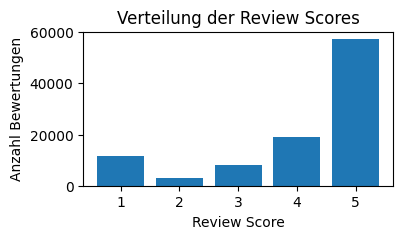

In [30]:
import matplotlib.pyplot as plt

# Aggregiert Review Scores zur Prüfung der Bewertungsverteilung
df_reviews = sql("""
                SELECT
                    review_score,
                    COUNT(*) AS review_count
                FROM order_reviews
                GROUP BY review_score
                ORDER BY review_score
                """)

# Erstellt ein Balkendiagramm der Verteilung der Review Scores
plt.figure(figsize=(4, 2))
plt.bar(df_reviews["review_score"], df_reviews["review_count"])
plt.xlabel("Review Score")
plt.ylabel("Anzahl Bewertungen")
plt.title("Verteilung der Review Scores")
plt.show()

Ergebnis:

Die Verteilung der Bewertungen ist stark rechtsschief.
Der Großteil der Bewertungen liegt bei 4 und 5 Sternen.

Die Skala 1–5 wird vollständig genutzt.
Es sind keine unplausiblen Häufungen oder fehlenden Werte erkennbar.

Die Bewertungsverteilung wirkt realistisch für einen Online-Marktplatz.

### 6.2 Deskriptive Kennzahlen der Artikelpreise

In [32]:
# Min, Max und Durchschnittspreis der bestellten Artikel
sql("""
    SELECT
        MIN(price) AS min_price,
        AVG(price) AS avg_price,
        MAX(price) AS max_price
    FROM order_items
    """)

,min_price,avg_price,max_price
0,0.85,120.653739,6735.0


### 6.3 Verteilung der bestellten Artikelpreise

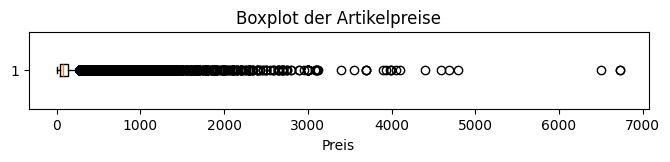

In [35]:
# Verteilung der bestellten Artikelpreise
df_price = sql("""
                SELECT price
                FROM order_items
                WHERE price IS NOT NULL
                """)

# Boxplot zur Darstellung der Verteilung der Artikelpreise
plt.figure(figsize=(8,1))
plt.boxplot(df_price["price"], vert = False)
plt.xlabel("Preis")
plt.title("Boxplot der Artikelpreise")
plt.show()

Die Lieferdauer wurde als Differenz zwischen Kaufzeitpunkt und tatsächlichem Lieferdatum berechnet.

Die Verteilung ist rechtsschief mit mehreren extremen Ausreißern.
Es sind keine negativen Lieferdauern vorhanden.

### 6.4 Verteilung der Lieferdauer (in Tagen)

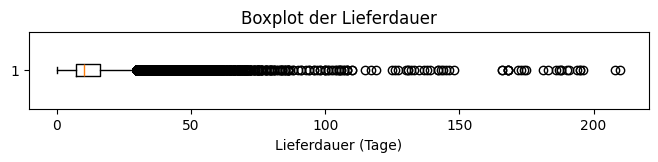

In [36]:
# Berechnet die Lieferdauer in Tagen (nur für tatsächlich ausgelieferte Bestellungen)
df_delivery = sql("""
                  SELECT
                      date_diff('day', order_purchase_timestamp, order_delivered_customer_date) 
                      AS delivery_days
                  FROM orders
                  WHERE order_status = 'delivered'
                    AND order_purchase_timestamp IS NOT NULL
                    AND order_delivered_customer_date IS NOT NULL
                  """)

# Boxplot zur Darstellung der Verteilung der Lieferdauer
plt.figure(figsize=(8,1))
plt.boxplot(df_delivery["delivery_days"], vert = False)
plt.xlabel("Lieferdauer (Tage)")
plt.title("Boxplot der Lieferdauer")
plt.show()

## **7. Fazit**

Im Rahmen dieses Notebooks wurden Struktur, Beziehungen und Datenqualität des Datensatzes systematisch untersucht.

Geprüft wurden insbesondere:

- Struktur und Beziehungen der relationalen Tabellen
- Vollständigkeit zentraler KPI-relevanter Felder
- Eindeutigkeit von Schlüsselattributen
- Logische Plausibilität von Zeitstempeln und numerischen Werten
- Zeitliche Abdeckung des Beobachtungszeitraums
- Verteilungen zentraler Variablen (Bewertungen, Preise, Lieferdauer)

Die Daten weisen keine kritischen Inkonsistenzen auf und sind grundsätzlich für eine weiterführende Verarbeitung geeignet.

Einschränkungen bestehen lediglich in der unvollständigen zeitlichen Abdeckung an den Randbereichen des Beobachtungszeitraums.


Weiteres Vorgehen (Notebook 02):

- Datenbereinigung auf Basis identifizierter Randfälle
- Behandlung zeitlicher Randbereiche
- Zusammenführung relevanter Tabellen
- Generierung abgeleiteter Variablen (z. B. Lieferdauer, Kundenkennzahlen)
- Aufbau eines analysefähigen Datensatzes